In [4]:
import pandas as pd
import re
import requests
import scipy as sp
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import csv
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [5]:
data = pd.read_csv('final route.csv')

print(data.head())
print(data.info())
print(f"Missing values:\n{data.isnull().sum()}")

    base_name              indication  mg_per_dose     dosing_period  \
0  adalimumab    rheumatoid arthritis         40.0  every other week   
1  adalimumab     psoriatic arthritis         40.0  every other week   
2  adalimumab  ankylosing spondylitis         40.0  every other week   
3  adalimumab         crohn's disease         40.0  every other week   
4  adalimumab      ulcerative colitis         40.0  every other week   

                                        dosage_forms         route  \
0  10/0.1 syringe|20/0.2 syringe|20/0.4 syringe|4...  subcutaneous   
1  10/0.1 syringe|20/0.2 syringe|20/0.4 syringe|4...  subcutaneous   
2  10/0.1 syringe|20/0.2 syringe|20/0.4 syringe|4...  subcutaneous   
3  10/0.1 syringe|20/0.2 syringe|20/0.4 syringe|4...  subcutaneous   
4  10/0.1 syringe|20/0.2 syringe|20/0.4 syringe|4...  subcutaneous   

   designated_daily_dose              ephmra_code  
0                   2.85  L4B (Anti-TNF Products)  
1                   2.85  L4B (Anti-TNF Pr

In [4]:
# Count unique products per EphMRA code (product-level), then by first-level EphMRA grouping.
def extract_first_level(code):
    if not isinstance(code, str):
        return None
    token = code.split('(')[0].strip()
    token = token.replace(' ', '')
    m = re.match(r'^([A-Za-z]+\d+)', token)
    return m.group(1) if m else token or None

# Ensure ephmra_code present
df = data.copy()
df = df.dropna(subset=['ephmra_code'])

# Full-code product counts (existing)
product_counts_by_ephmra = (
    df.groupby('ephmra_code')
    .agg(unique_products=('base_name', 'nunique'), total_rows=('base_name', 'size'))
    .sort_values(['unique_products', 'total_rows'], ascending=[False, False])
)
product_counts_by_ephmra = product_counts_by_ephmra.reset_index()
product_counts_by_ephmra['ephmra_code'] = product_counts_by_ephmra['ephmra_code'].astype(str).str.split('(').str[0].str.strip()
product_counts_by_ephmra = product_counts_by_ephmra.set_index('ephmra_code')

print('Unique products per full EphMRA code:')
print(product_counts_by_ephmra.head(40))

df['ephmra_token'] = df['ephmra_code'].astype(str).apply(lambda s: s.split('(')[0].strip())
# First-level grouping (consistent single prefix like 'L1', 'C10', 'N7')
df['ephmra_one'] = df['ephmra_token'].apply(extract_first_level)

one_level_counts = (
    df.dropna(subset=['ephmra_one'])
    .groupby('ephmra_one')
    .agg(unique_products=('base_name', 'nunique'), total_rows=('base_name', 'size'))
    .sort_values(['unique_products', 'total_rows'], ascending=[False, False])
)

print('\nUnique products per EphMRA first-level grouping:')
print(one_level_counts.head(60))


Unique products per full EphMRA code:
             unique_products  total_rows
ephmra_code                             
L1G9                      29          59
L1G5                      11          65
L4C                       10          33
L1G3                       7          16
L1G1                       6          22
L4B                        4          29
N7A                        4          13
L1G4                       4          11
L4E                        4          10
R3M                        4           9
M5X                        4           5
N2C2                       4           5
S1P                        3          10
L4X                        3           6
D5X                        3           4
L1G2                       2          16
C10A4                      2           8
R3X2                       2           5
N7X                        2           4
J1X9                       2           3
L4X                        2           3
N7D9               

In [6]:
# Model 1: daily dose distribution across full EphMRA codes using one daily dose per unique product.
def parse_daily_dose(value):
    if pd.isna(value):
        return np.nan
    parts = [part.strip() for part in str(value).split('|') if part.strip()]
    numeric_parts = pd.to_numeric(pd.Series(parts), errors='coerce').dropna()
    if numeric_parts.empty:
        return np.nan
    return round(float(numeric_parts.mean()), 2)

dose_df = data[['base_name', 'ephmra_code', 'designated_daily_dose']].dropna(subset=['base_name', 'ephmra_code', 'designated_daily_dose']).copy()
dose_df['daily_dose_avg'] = dose_df['designated_daily_dose'].apply(parse_daily_dose)
dose_df = dose_df.dropna(subset=['daily_dose_avg'])

# Build one representative daily dose per unique product by taking the most frequent value across indications.
product_daily_dose = (
    dose_df.groupby(['ephmra_code', 'base_name'], as_index=False)
    .agg(
        representative_daily_dose=('daily_dose_avg', lambda s: s.value_counts().sort_index(ascending=True).idxmax()),
        indication_rows=('daily_dose_avg', 'size'),
    )
)

ephmra_product_counts = (
    product_daily_dose.groupby('ephmra_code')['base_name']
    .nunique()
    .reset_index(name='unique_products')
)
eligible_ephmra_codes = ephmra_product_counts.loc[ephmra_product_counts['unique_products'] > 3, 'ephmra_code']

model1_df = product_daily_dose[product_daily_dose['ephmra_code'].isin(eligible_ephmra_codes)].copy()

model1_summary = (
    model1_df.groupby('ephmra_code')['representative_daily_dose']
    .agg(n='count', mean='mean', std='std', median='median', min='min', max='max')
    .sort_values(['n', 'mean'], ascending=[False, True])
)
model1_summary = model1_summary.reset_index()
model1_summary['ephmra_code'] = model1_summary['ephmra_code'].astype(str).str.split('(').str[0].str.strip()
model1_summary = model1_summary.set_index('ephmra_code')

print('=== MODEL 1: Representative daily dose distribution by full EphMRA code ===')
print('Unique product daily dose definition:')
print('- If designated_daily_dose contains multiple values separated by |, they are averaged first.')
print('- If a base_name appears multiple times across indications, the most frequent daily dose is kept.')
print('- Only full EphMRA codes with more than 3 unique products are included.')
print()
print(model1_summary)

# Optional normal fit parameters for each code.
model1_normal_fit_rows = []
for ephmra_code, group in model1_df.groupby('ephmra_code'):
    values = group['representative_daily_dose'].dropna().to_numpy()
    if len(values) == 0:
        continue
    normal_mu, normal_sigma = sp.stats.norm.fit(values)
    model1_normal_fit_rows.append({
        'ephmra_code': ephmra_code,
        'normal_mu': normal_mu,
        'normal_sigma': normal_sigma,
    })
model1_normal_fit = pd.DataFrame(model1_normal_fit_rows).sort_values('normal_mu', ascending=False)
model1_normal_fit['ephmra_code'] = model1_normal_fit['ephmra_code'].astype(str).str.split('(').str[0].str.strip()
model1_normal_fit = model1_normal_fit.set_index('ephmra_code')

print()
print('=== MODEL 1: Normal fit parameters by full EphMRA code ===')
print(model1_normal_fit)


=== MODEL 1: Representative daily dose distribution by full EphMRA code ===
Unique product daily dose definition:
- If designated_daily_dose contains multiple values separated by |, they are averaged first.
- If a base_name appears multiple times across indications, the most frequent daily dose is kept.
- Only full EphMRA codes with more than 3 unique products are included.

              n       mean        std  median    min    max
ephmra_code                                                
L1G9         29  15.192069  19.472956   5.870   0.01  64.11
L1G5         11  25.405455  20.226767  16.780   8.77  56.99
L4C          10   7.447000   6.974962   4.275   1.64  21.37
L1G3          7  39.900000  30.747718  27.950  11.74  99.73
L1G1          6   3.308333   3.991618   1.570   0.04  10.48
R3M           4   3.020000   3.300757   2.055   0.49   7.48
N2C2          4   4.047500   2.428228   3.300   2.19   7.40
N7A           4   4.232500   4.456130   2.880   0.49  10.68
L4B           4   6.15

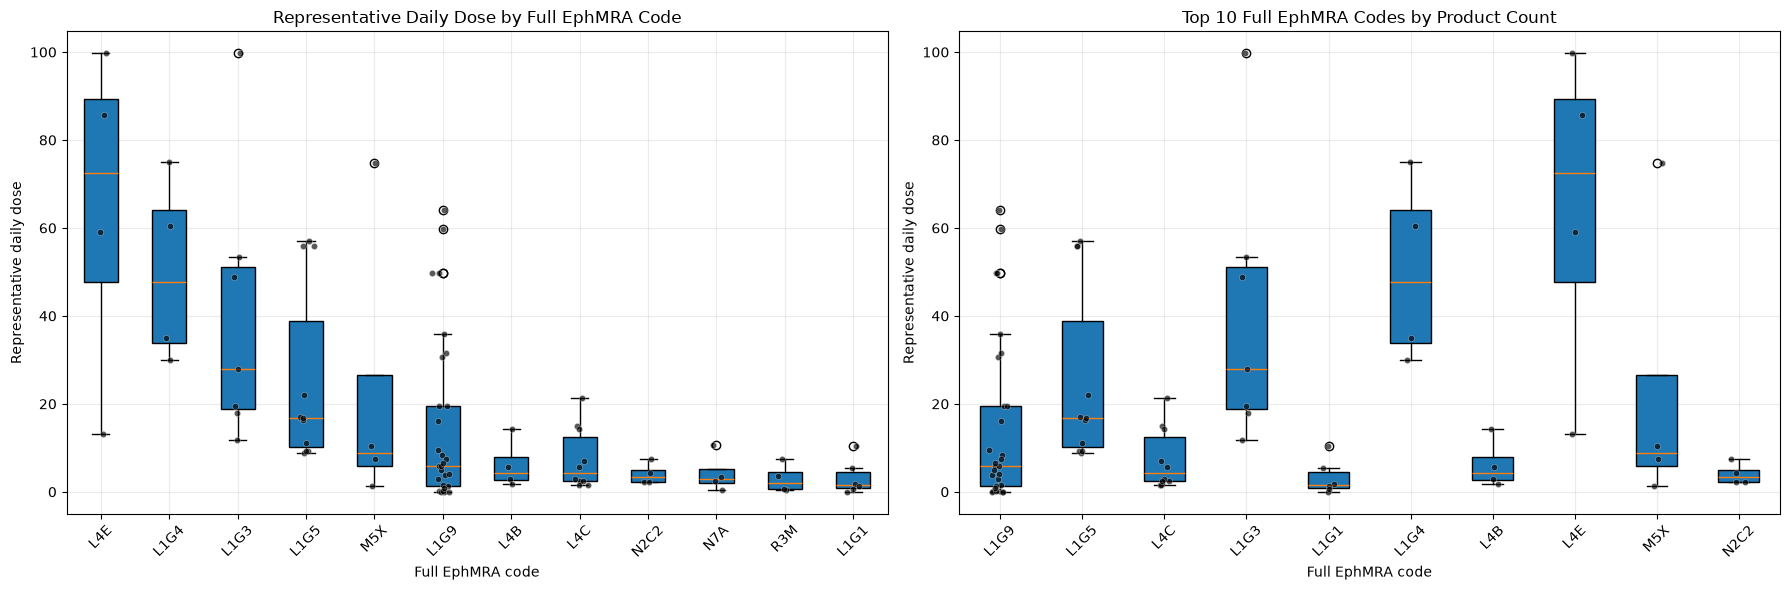

In [7]:
# MODEL 1 box plots (representative daily-dose distributions by full EphMRA code)
if 'model1_df' not in globals():
    print('Run Model 1 first to create model1_df.')
else:
    plot_df = model1_df[['ephmra_code', 'base_name', 'representative_daily_dose']].copy()
    plot_df['ephmra_code_short'] = plot_df['ephmra_code'].astype(str).str.split('(').str[0].str.strip()
    plot_df = plot_df.dropna(subset=['representative_daily_dose'])

    # Full panel order: by median representative daily dose (descending)
    code_order = (
        plot_df.groupby('ephmra_code')['representative_daily_dose']
        .median()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    # Top-10 panel order: by unique product count (descending)
    top_code_order = (
        plot_df.groupby('ephmra_code')['base_name']
        .nunique()
        .sort_values(ascending=False)
        .head(10)
        .index
        .tolist()
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    def boxplot_with_dots(ax, frame, order, title):
        groups = [frame.loc[frame['ephmra_code'] == code, 'representative_daily_dose'].values for code in order]
        label_map = frame.drop_duplicates('ephmra_code').set_index('ephmra_code')['ephmra_code_short'].to_dict()
        display_labels = [label_map.get(code, code) for code in order]

        ax.boxplot(groups, tick_labels=display_labels, patch_artist=True)
        for idx, values in enumerate(groups, start=1):
            jitter = np.random.normal(loc=idx, scale=0.05, size=len(values))
            ax.scatter(jitter, values, s=20, alpha=0.65, color='black', edgecolors='white', linewidths=0.3, zorder=3)
        ax.set_title(title)
        ax.set_xlabel('Full EphMRA code')
        ax.set_ylabel('Representative daily dose')
        ax.grid(alpha=0.25)
        ax.tick_params(axis='x', rotation=45)

    # Box plot A: all eligible full EphMRA codes
    boxplot_with_dots(axes[0], plot_df, code_order, 'Representative Daily Dose by Full EphMRA Code')

    # Box plot B: top 10 codes by unique product count
    top_plot_df = plot_df[plot_df['ephmra_code'].isin(top_code_order)].copy()
    boxplot_with_dots(axes[1], top_plot_df, top_code_order, 'Top 10 Full EphMRA Codes by Product Count')

    plt.tight_layout()
    plt.show()

In [8]:
# MODEL 1 significance + predictive validation (EphMRA code -> representative daily dose)
if 'model1_df' not in globals() or len(model1_df) == 0:
    print('Run Model 1 first to create model1_df.')
else:
    from sklearn.model_selection import KFold
    from sklearn.metrics import mean_squared_error

    stats_df = model1_df[['ephmra_code', 'base_name', 'representative_daily_dose']].dropna().copy()
    stats_df['ephmra_code_short'] = stats_df['ephmra_code'].astype(str).str.split('(').str[0].str.strip()
    stats_df['log_dose'] = np.log1p(stats_df['representative_daily_dose'])

    # ----- 1) Global significance tests across EphMRA groups -----
    grouped = [g['log_dose'].values for _, g in stats_df.groupby('ephmra_code_short')]
    k_groups = len(grouped)
    n_total = len(stats_df)

    if k_groups < 2:
        print('Not enough EphMRA groups for inferential testing.')
    else:
        # One-way ANOVA on log-dose
        anova_f, anova_p = sp.stats.f_oneway(*grouped)

        # Eta-squared effect size
        grand_mean = stats_df['log_dose'].mean()
        ss_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in grouped)
        ss_total = np.sum((stats_df['log_dose'] - grand_mean) ** 2)
        eta_squared = ss_between / ss_total if ss_total > 0 else np.nan

        # Kruskal-Wallis (non-parametric)
        kruskal_h, kruskal_p = sp.stats.kruskal(*grouped)
        epsilon_squared = (kruskal_h - k_groups + 1) / (n_total - k_groups) if (n_total - k_groups) > 0 else np.nan

        inferential_summary = pd.DataFrame([
            {
                'test': 'ANOVA on log1p(dose)',
                'statistic': anova_f,
                'p_value': anova_p,
                'effect_size_name': 'eta_squared',
                'effect_size': eta_squared,
            },
            {
                'test': 'Kruskal-Wallis on log1p(dose)',
                'statistic': kruskal_h,
                'p_value': kruskal_p,
                'effect_size_name': 'epsilon_squared',
                'effect_size': epsilon_squared,
            },
        ])

        print('=== MODEL 1: Global significance tests (EphMRA code vs representative daily dose) ===')
        print(inferential_summary.round(6).to_string(index=False))

    # ----- 2) Predictive validation: baseline vs EphMRA-only model -----
    # Baseline predicts train-fold mean dose; model predicts from EphMRA code only.
    X = stats_df[['ephmra_code_short']].copy()
    y = stats_df['representative_daily_dose'].values

    n_splits = 5 if len(stats_df) >= 25 else 3
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    baseline_rows = []
    model_rows = []

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Baseline
        yhat_base = np.repeat(np.mean(y_train), len(y_test))
        baseline_rows.append({
            'fold': fold_idx,
            'r2': r2_score(y_test, yhat_base),
            'mae': mean_absolute_error(y_test, yhat_base),
            'rmse': mean_squared_error(y_test, yhat_base) ** 0.5,
        })

        # EphMRA-only model
        model = Pipeline(steps=[
            ('prep', ColumnTransformer(
                transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), ['ephmra_code_short'])],
                remainder='drop',
            )),
            ('reg', LinearRegression()),
        ])
        model.fit(X_train, y_train)
        yhat_model = model.predict(X_test)

        model_rows.append({
            'fold': fold_idx,
            'r2': r2_score(y_test, yhat_model),
            'mae': mean_absolute_error(y_test, yhat_model),
            'rmse': mean_squared_error(y_test, yhat_model) ** 0.5,
        })

    baseline_cv = pd.DataFrame(baseline_rows)
    model_cv = pd.DataFrame(model_rows)

    cv_summary = pd.DataFrame([
        {
            'model': 'Baseline (global mean)',
            'cv_r2_mean': baseline_cv['r2'].mean(),
            'cv_mae_mean': baseline_cv['mae'].mean(),
            'cv_rmse_mean': baseline_cv['rmse'].mean(),
        },
        {
            'model': 'EphMRA-only linear model',
            'cv_r2_mean': model_cv['r2'].mean(),
            'cv_mae_mean': model_cv['mae'].mean(),
            'cv_rmse_mean': model_cv['rmse'].mean(),
        },
    ])

    uplift = pd.DataFrame([
        {
            'metric': 'delta_r2 (model - baseline)',
            'value': model_cv['r2'].mean() - baseline_cv['r2'].mean(),
        },
        {
            'metric': 'mae_reduction_pct',
            'value': 100 * (baseline_cv['mae'].mean() - model_cv['mae'].mean()) / baseline_cv['mae'].mean() if baseline_cv['mae'].mean() != 0 else np.nan,
        },
        {
            'metric': 'rmse_reduction_pct',
            'value': 100 * (baseline_cv['rmse'].mean() - model_cv['rmse'].mean()) / baseline_cv['rmse'].mean() if baseline_cv['rmse'].mean() != 0 else np.nan,
        },
    ])

    print('\n=== MODEL 1: Cross-validated predictive performance ===')
    print(cv_summary.round(6).to_string(index=False))
    print('\n=== MODEL 1: Predictive uplift from EphMRA code ===')
    print(uplift.round(6).to_string(index=False))

    # ----- 3) Permutation test on predictive R2 -----
    # Null: EphMRA labels are not related to dose.
    observed_r2 = model_cv['r2'].mean()
    n_perm = 500
    perm_r2 = []

    split_indices = list(kf.split(X))
    for i in range(n_perm):
        X_perm = X.copy()
        X_perm['ephmra_code_short'] = np.random.permutation(X_perm['ephmra_code_short'].values)

        fold_r2 = []
        for train_idx, test_idx in split_indices:
            X_train, X_test = X_perm.iloc[train_idx], X_perm.iloc[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            perm_model = Pipeline(steps=[
                ('prep', ColumnTransformer(
                    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), ['ephmra_code_short'])],
                    remainder='drop',
                )),
                ('reg', LinearRegression()),
            ])
            perm_model.fit(X_train, y_train)
            yhat_perm = perm_model.predict(X_test)
            fold_r2.append(r2_score(y_test, yhat_perm))

        perm_r2.append(np.mean(fold_r2))

    perm_r2 = np.array(perm_r2)
    p_perm = (np.sum(perm_r2 >= observed_r2) + 1) / (n_perm + 1)

    permutation_summary = pd.DataFrame([
        {
            'observed_cv_r2': observed_r2,
            'perm_mean_r2': perm_r2.mean(),
            'perm_std_r2': perm_r2.std(ddof=1),
            'perm_p_value_one_sided': p_perm,
            'n_permutations': n_perm,
        }
    ])

    print('\n=== MODEL 1: Permutation test for predictive signal ===')
    print(permutation_summary.round(6).to_string(index=False))


=== MODEL 1: Global significance tests (EphMRA code vs representative daily dose) ===
                         test  statistic  p_value effect_size_name  effect_size
         ANOVA on log1p(dose)   5.099972 0.000006      eta_squared     0.415247
Kruskal-Wallis on log1p(dose)  38.116502 0.000075  epsilon_squared     0.343247

=== MODEL 1: Cross-validated predictive performance ===
                   model  cv_r2_mean  cv_mae_mean  cv_rmse_mean
  Baseline (global mean)   -0.066565    18.484620     24.000795
EphMRA-only linear model    0.213366    15.047911     20.768448

=== MODEL 1: Predictive uplift from EphMRA code ===
                     metric     value
delta_r2 (model - baseline)  0.279931
          mae_reduction_pct 18.592263
         rmse_reduction_pct 13.467664

=== MODEL 1: Permutation test for predictive signal ===
 observed_cv_r2  perm_mean_r2  perm_std_r2  perm_p_value_one_sided  n_permutations
       0.213366     -0.328627     0.165439                0.001996             5

In [7]:
# MODEL 1: predicted representative daily dose per EphMRA code (expanded stats, cross-validated bias)
if 'model1_df' not in globals() or len(model1_df) == 0:
    print('Run Model 1 first to create model1_df.')
else:
    from sklearn.model_selection import KFold

    pred_df = model1_df[['ephmra_code', 'base_name', 'representative_daily_dose']].dropna().copy()
    pred_df['ephmra_code_short'] = pred_df['ephmra_code'].astype(str).str.split('(').str[0].str.strip()

    # Build out-of-fold predictions so per-code bias is measured out-of-sample.
    n_rows = len(pred_df)
    n_splits = 5 if n_rows >= 25 else 3
    n_splits = min(n_splits, n_rows)

    if n_splits < 2:
        print('Not enough rows for cross-validated prediction summary.')
    else:
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        oof_pred = np.zeros(n_rows, dtype=float)

        X_all = pred_df[['ephmra_code_short']].copy()
        y_all = pred_df['representative_daily_dose'].values

        for train_idx, test_idx in kf.split(X_all):
            X_train, X_test = X_all.iloc[train_idx], X_all.iloc[test_idx]
            y_train = y_all[train_idx]

            fold_model = Pipeline(steps=[
                ('prep', ColumnTransformer(
                    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), ['ephmra_code_short'])],
                    remainder='drop',
                )),
                ('reg', LinearRegression()),
            ])

            fold_model.fit(X_train, y_train)
            oof_pred[test_idx] = fold_model.predict(X_test)

        pred_df['cv_predicted_daily_dose'] = oof_pred
        pred_df['cv_residual'] = pred_df['representative_daily_dose'] - pred_df['cv_predicted_daily_dose']

        # Build per-code summary using cross-validated (out-of-fold) predictions.
        predictions_per_code = (
            pred_df.groupby('ephmra_code_short')
            .agg(
                n_products=('base_name', 'nunique'),
                actual_mean_daily_dose=('representative_daily_dose', 'mean'),
                cv_predicted_daily_dose=('cv_predicted_daily_dose', 'mean'),
                std_daily_dose=('representative_daily_dose', 'std'),
                median_daily_dose=('representative_daily_dose', 'median'),
                q1_daily_dose=('representative_daily_dose', lambda s: s.quantile(0.25)),
                q3_daily_dose=('representative_daily_dose', lambda s: s.quantile(0.75)),
                min_daily_dose=('representative_daily_dose', 'min'),
                max_daily_dose=('representative_daily_dose', 'max'),
                cv_mae_within_code=('cv_residual', lambda s: np.mean(np.abs(s))),
                cv_rmse_within_code=('cv_residual', lambda s: np.sqrt(np.mean(np.square(s)))),
            )
            .sort_values(['n_products', 'cv_predicted_daily_dose'], ascending=[False, False])
        )

        predictions_per_code['se_mean'] = predictions_per_code['std_daily_dose'] / np.sqrt(predictions_per_code['n_products'])
        predictions_per_code['ci95_low'] = predictions_per_code['actual_mean_daily_dose'] - 1.96 * predictions_per_code['se_mean']
        predictions_per_code['ci95_high'] = predictions_per_code['actual_mean_daily_dose'] + 1.96 * predictions_per_code['se_mean']
        predictions_per_code['ci95_half_width'] = 1.96 * predictions_per_code['se_mean']
        predictions_per_code['iqr_daily_dose'] = predictions_per_code['q3_daily_dose'] - predictions_per_code['q1_daily_dose']
        predictions_per_code['cv_pct'] = np.where(
            predictions_per_code['actual_mean_daily_dose'] != 0,
            100 * predictions_per_code['std_daily_dose'] / predictions_per_code['actual_mean_daily_dose'],
            np.nan,
        )
        predictions_per_code['cv_bias_pred_minus_actual'] = (
            predictions_per_code['cv_predicted_daily_dose'] - predictions_per_code['actual_mean_daily_dose']
        )

        predictions_per_code['cv_predicted_daily_dose_ci95'] = predictions_per_code.apply(
            lambda r: f"{r['cv_predicted_daily_dose']:.2f} (+/- {r['ci95_half_width']:.2f} CI95)",
            axis=1,
        )

        ordered_cols = [
            'n_products',
            'actual_mean_daily_dose',
            'cv_predicted_daily_dose_ci95',
            'cv_bias_pred_minus_actual',
            'std_daily_dose',
            'se_mean',
            'ci95_low',
            'ci95_high',
            'median_daily_dose',
            'q1_daily_dose',
            'q3_daily_dose',
            'iqr_daily_dose',
            'min_daily_dose',
            'max_daily_dose',
            'cv_pct',
            'cv_mae_within_code',
            'cv_rmse_within_code',
        ]

        print('=== MODEL 1: Cross-validated predictions per EphMRA code (expanded statistics) ===')
        print(predictions_per_code[ordered_cols].round(4).to_string())


=== MODEL 1: Cross-validated predictions per EphMRA code (expanded statistics) ===
                   n_products  actual_mean_daily_dose cv_predicted_daily_dose_ci95  cv_bias_pred_minus_actual  std_daily_dose  se_mean  ci95_low  ci95_high  median_daily_dose  q1_daily_dose  q3_daily_dose  iqr_daily_dose  min_daily_dose  max_daily_dose    cv_pct  cv_mae_within_code  cv_rmse_within_code
ephmra_code_short                                                                                                                                                                                                                                                                                              
L1G9                       29                 15.1921        14.81 (+/- 7.09 CI95)                    -0.3835         19.4730   3.6160    8.1046    22.2795              5.870         1.4000        19.5600         18.1600            0.01           64.11  128.1784             16.9603              20.6088
L1G5 

In [16]:
# MODEL 1: outlier review by EphMRA code with original CSV row indices
if 'data' not in globals():
    print('Load the data first.')
else:
    def parse_daily_dose_for_review(value):
        if pd.isna(value):
            return np.nan
        parts = [part.strip() for part in str(value).split('|') if part.strip()]
        numeric_parts = pd.to_numeric(pd.Series(parts), errors='coerce').dropna()
        if numeric_parts.empty:
            return np.nan
        return float(numeric_parts.mean())

    # Preserve original CSV row numbers for manual review.
    review_df = data.reset_index().rename(columns={'index': 'csv_row_index'}).copy()
    review_df['csv_line_number'] = review_df['csv_row_index'] + 2
    review_df['daily_dose_avg'] = review_df['designated_daily_dose'].apply(parse_daily_dose_for_review)
    review_df['ephmra_code_short'] = review_df['ephmra_code'].astype(str).str.split('(').str[0].str.strip()

    # Collapse to one product-level row per EphMRA code and base_name while retaining source rows.
    product_review_df = (
        review_df.dropna(subset=['ephmra_code_short', 'base_name', 'daily_dose_avg'])
        .groupby(['ephmra_code_short', 'base_name'], as_index=False)
        .agg(
            representative_daily_dose=('daily_dose_avg', lambda s: s.value_counts().sort_index(ascending=True).idxmax()),
            n_source_rows=('csv_row_index', 'size'),
            source_row_indices=('csv_row_index', lambda s: sorted(s.unique().tolist())),
            source_line_numbers=('csv_line_number', lambda s: sorted(s.unique().tolist())),
        )
    )

    # IQR outlier bounds within each EphMRA code.
    bounds_df = (
        product_review_df.groupby('ephmra_code_short')['representative_daily_dose']
        .agg(q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75))
        .reset_index()
    )
    bounds_df['iqr'] = bounds_df['q3'] - bounds_df['q1']
    bounds_df['lower_bound'] = bounds_df['q1'] - 1.5 * bounds_df['iqr']
    bounds_df['upper_bound'] = bounds_df['q3'] + 1.5 * bounds_df['iqr']

    outlier_df = product_review_df.merge(bounds_df, on='ephmra_code_short', how='left')
    outlier_df = outlier_df[
        (outlier_df['representative_daily_dose'] < outlier_df['lower_bound']) |
        (outlier_df['representative_daily_dose'] > outlier_df['upper_bound'])
    ].copy()

    print('=== MODEL 1: IQR outliers by EphMRA code ===')
    if len(outlier_df) == 0:
        print('No IQR outliers found at the product level.')
    else:
        outlier_df['source_row_indices'] = outlier_df['source_row_indices'].apply(lambda x: ', '.join(map(str, x)))
        outlier_df['source_line_numbers'] = outlier_df['source_line_numbers'].apply(lambda x: ', '.join(map(str, x)))

        display_cols = [
            'ephmra_code_short',
            'base_name',
            'representative_daily_dose',
            'q1',
            'q3',
            'iqr',
            'lower_bound',
            'upper_bound',
            'n_source_rows',
            'source_row_indices',
            'source_line_numbers',
        ]

        print(outlier_df[display_cols].sort_values(['ephmra_code_short', 'representative_daily_dose']).round(4).to_string(index=False))

        # Show the exact source CSV rows for manual review.
        source_row_ids = sorted({idx for indices in outlier_df['source_row_indices'].str.split(', ').tolist() for idx in indices})
        source_row_ids = [int(idx) for idx in source_row_ids if str(idx).strip() != '']
        review_rows = review_df[review_df['csv_row_index'].isin(source_row_ids)].copy()
        review_rows = review_rows.sort_values(['ephmra_code_short', 'base_name', 'csv_row_index'])

        print('\n=== Source CSV rows for outlier products ===')
        print(
            review_rows[
                ['csv_row_index', 'csv_line_number', 'base_name', 'indication', 'designated_daily_dose', 'ephmra_code']
            ]
            .to_string(index=False)
        )


=== MODEL 1: IQR outliers by EphMRA code ===
ephmra_code_short   base_name  representative_daily_dose      q1      q3     iqr  lower_bound  upper_bound  n_source_rows                                         source_row_indices                                        source_line_numbers
             L1G1   rituximab                      10.48  0.8900  4.5375  3.6475      -4.5813      10.0088             12 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322
             L1G3 zanidatamab                      99.73 18.7800 51.1600 32.3800     -29.7900      99.7300              1                                                        373                                                        375
             L1G9  elotuzumab                      49.86  1.4000 19.5600 18.1600     -25.8400      46.8000              2                                                   132, 133                                                   134,

In [17]:
# Count unique products per EphMRA code (product-level), then by first-level EphMRA grouping.
def extract_first_level(code):
    if not isinstance(code, str):
        return None
    token = code.split('(')[0].strip()
    token = token.replace(' ', '')
    m = re.match(r'^([A-Za-z]+\d+)', token)
    return m.group(1) if m else token or None

# Ensure ephmra_code present
df = data.copy()
df = df.dropna(subset=['ephmra_code'])
df['indication'] = df['indication'].str.lower()

# Full-code product counts (existing)
indication_counts_by_ephmra = (
    df.groupby('ephmra_code')
    .agg(unique_indications=('indication', 'nunique'), total_rows=('indication', 'size'))
    .sort_values(['unique_indications', 'total_rows'], ascending=[False, False])
)
indication_counts_by_ephmra = indication_counts_by_ephmra.reset_index()
indication_counts_by_ephmra['ephmra_code'] = indication_counts_by_ephmra['ephmra_code'].astype(str).str.split('(').str[0].str.strip()
indication_counts_by_ephmra = indication_counts_by_ephmra.set_index('ephmra_code')

print('Unique indications per full EphMRA code:')
print(indication_counts_by_ephmra.head(40))

df['ephmra_token'] = df['ephmra_code'].astype(str).apply(lambda s: s.split('(')[0].strip())
# First-level grouping (consistent single prefix like 'L1', 'C10', 'N7')
df['ephmra_one'] = df['ephmra_token'].apply(extract_first_level)

one_level_counts = (
    df.dropna(subset=['ephmra_one'])
    .groupby('ephmra_one')
    .agg(unique_indications=('indication', 'nunique'), total_rows=('indication', 'size'))
    .sort_values(['unique_indications', 'total_rows'], ascending=[False, False])
)

print('\nUnique indications per EphMRA first-level grouping:')
print(one_level_counts.head(60))

Unique indications per full EphMRA code:
             unique_indications  total_rows
ephmra_code                                
L1G9                         58          59
L1G5                         53          65
L4C                          26          33
L1G1                         21          22
L1G2                         15          16
L1G3                         14          16
L1G4                         11          11
L4E                          10          10
L4B                           9          29
N7A                           9          13
M5B9                          8           8
R3M                           7           9
C10A4                         7           8
S1P                           6          10
M1C                           5           7
M5X                           5           5
L4X                           4           6
N2C2                          4           5
R3X2                          4           5
N7X                           4    

In [18]:
df = data.copy()
df['indication'] = df['indication'].str.lower()

ephmra_counts_by_indication = (
    df.groupby('indication')
    .agg(unique_ephmra=('ephmra_code', 'nunique'), total_rows=('ephmra_code', 'size'))
    .sort_values(['unique_ephmra', 'total_rows'], ascending=[False, False])
)
ephmra_counts_by_indication = ephmra_counts_by_indication.reset_index()
ephmra_counts_by_indication['indication'] = ephmra_counts_by_indication['indication'].astype(str).str.split('(').str[0].str.strip()
ephmra_counts_by_indication = ephmra_counts_by_indication.set_index('indication')

print('Unique EphMRA codes per indication:')
print(ephmra_counts_by_indication.head(40))


Unique EphMRA codes per indication:
                                                  unique_ephmra  total_rows
indication                                                                 
rheumatoid arthritis                                          4           9
psoriatic arthritis                                           3          10
crohn's disease                                               3           7
ulcerative colitis                                            3           6
relapsing forms of multiple sclerosis                         3           5
chronic rhinosinusitis with nasal polyps                      3           4
hepatocellular carcinoma                                      3           4
ankylosing spondylitis                                        2           7
plaque psoriasis                                              2           6
active lupus nephritis                                        2           3
gastric cancer                                      

In [22]:

df = data.copy()
df['indication'] = df['indication'].str.lower()
df['base_name'] = df['base_name'].str.lower()
df = df.dropna(subset=['indication'])

drug_counts_by_indication = (
    df.groupby('indication')
    .agg(unique_base=('base_name', 'nunique'), total_rows=('base_name', 'size'))
    .sort_values(['unique_base', 'total_rows'], ascending=[False, False])
)
drug_counts_by_indication = drug_counts_by_indication.reset_index()
drug_counts_by_indication['indication'] = drug_counts_by_indication['indication'].astype(str).str.split('(').str[0].str.strip()
drug_counts_by_indication = drug_counts_by_indication.set_index('indication')

print('Unique base names per indication:')
print(drug_counts_by_indication.head(40))


Unique base names per indication:
                                                  unique_base  total_rows
indication                                                               
psoriatic arthritis                                         9           9
crohn's disease                                             7           7
ankylosing spondylitis                                      6           6
plaque psoriasis                                            6           6
rheumatoid arthritis                                        6           6
ulcerative colitis                                          6           6
relapsing forms of multiple sclerosis                       4           4
diabetic macular edema                                      3           3
hepatocellular carcinoma                                    3           3
merkel cell carcinoma                                       3           3
non-radiographic axial spondyloarthritis                    3           3
adju

In [8]:
# Model 2: daily dose distribution across full EphMRA codes and route using one daily dose per unique product.
def parse_daily_dose_model2(value):
    if pd.isna(value):
        return np.nan
    parts = [part.strip() for part in str(value).split('|') if part.strip()]
    numeric_parts = pd.to_numeric(pd.Series(parts), errors='coerce').dropna()
    if numeric_parts.empty:
        return np.nan
    return round(float(numeric_parts.mean()), 2)

model2_df_raw = data[['base_name', 'ephmra_code', 'route', 'designated_daily_dose']].dropna(
    subset=['base_name', 'ephmra_code', 'route', 'designated_daily_dose']
).copy()
model2_df_raw['route'] = model2_df_raw['route'].astype(str).str.strip().str.lower()
model2_df_raw['daily_dose_avg'] = model2_df_raw['designated_daily_dose'].apply(parse_daily_dose_model2)
model2_df_raw = model2_df_raw.dropna(subset=['daily_dose_avg'])

route_count = model2_df_raw['route'].nunique()
print(f'Routes found in data: {route_count}')
print('Route values:', sorted(model2_df_raw['route'].unique().tolist()))
if route_count != 3:
    print('Warning: Expected 3 routes but found a different count in current data.')

# Build one representative daily dose per unique product within each EphMRA code and route.
product_daily_dose_model2 = (
    model2_df_raw.groupby(['ephmra_code', 'route', 'base_name'], as_index=False)
    .agg(
        representative_daily_dose=('daily_dose_avg', lambda s: s.value_counts().sort_index(ascending=True).idxmax()),
        indication_rows=('daily_dose_avg', 'size'),
    )
)

combo_product_counts = (
    product_daily_dose_model2.groupby(['ephmra_code', 'route'])['base_name']
    .nunique()
    .reset_index(name='unique_products')
)
eligible_combos = combo_product_counts[combo_product_counts['unique_products'] > 3][['ephmra_code', 'route']]

model2_df = product_daily_dose_model2.merge(eligible_combos, on=['ephmra_code', 'route'], how='inner')

model2_summary = (
    model2_df.groupby(['ephmra_code', 'route'])['representative_daily_dose']
    .agg(n='count', mean='mean', std='std', median='median', min='min', max='max')
    .sort_values(['n', 'mean'], ascending=[False, True])
    .reset_index()
)
model2_summary['ephmra_code'] = model2_summary['ephmra_code'].astype(str).str.split('(').str[0].str.strip()
model2_summary = model2_summary.set_index(['ephmra_code', 'route'])

print('\n=== MODEL 2: Representative daily dose distribution by full EphMRA code and route ===')
print('Unique product daily dose definition:')
print('- If designated_daily_dose contains multiple values separated by |, they are averaged first.')
print('- If a base_name appears multiple times across indications within the same route, the most frequent daily dose is kept.')
print('- Only EphMRA code + route groups with more than 3 unique products are included.')
print()
print(model2_summary)

# Optional normal fit parameters for each EphMRA code + route group.
model2_normal_fit_rows = []
for (ephmra_code, route), group in model2_df.groupby(['ephmra_code', 'route']):
    values = group['representative_daily_dose'].dropna().to_numpy()
    if len(values) == 0:
        continue
    normal_mu, normal_sigma = sp.stats.norm.fit(values)
    model2_normal_fit_rows.append({
        'ephmra_code': ephmra_code,
        'route': route,
        'normal_mu': normal_mu,
        'normal_sigma': normal_sigma,
    })

model2_normal_fit = pd.DataFrame(model2_normal_fit_rows)
if len(model2_normal_fit) > 0:
    model2_normal_fit['ephmra_code'] = model2_normal_fit['ephmra_code'].astype(str).str.split('(').str[0].str.strip()
    model2_normal_fit = model2_normal_fit.sort_values('normal_mu', ascending=False).set_index(['ephmra_code', 'route'])

print()
print('=== MODEL 2: Normal fit parameters by full EphMRA code and route ===')
if len(model2_normal_fit_rows) == 0:
    print('No eligible EphMRA code + route groups were available for normal fitting.')
else:
    print(model2_normal_fit)


Routes found in data: 3
Route values: ['intravenous', 'intravitreal', 'subcutaneous']

=== MODEL 2: Representative daily dose distribution by full EphMRA code and route ===
Unique product daily dose definition:
- If designated_daily_dose contains multiple values separated by |, they are averaged first.
- If a base_name appears multiple times across indications within the same route, the most frequent daily dose is kept.
- Only EphMRA code + route groups with more than 3 unique products are included.

                           n       mean        std  median    min    max
ephmra_code route                                                       
L1G9        intravenous   27  14.995556  18.238281   5.870   0.01  59.84
L1G5        intravenous   11  25.405455  20.226767  16.780   8.77  56.99
L4C         subcutaneous  10   8.268000   6.805163   6.410   1.64  21.37
L1G3        intravenous    7  41.607143  30.302173  39.900  11.74  99.73
L1G1        intravenous    4   4.357500   4.688855   3.4

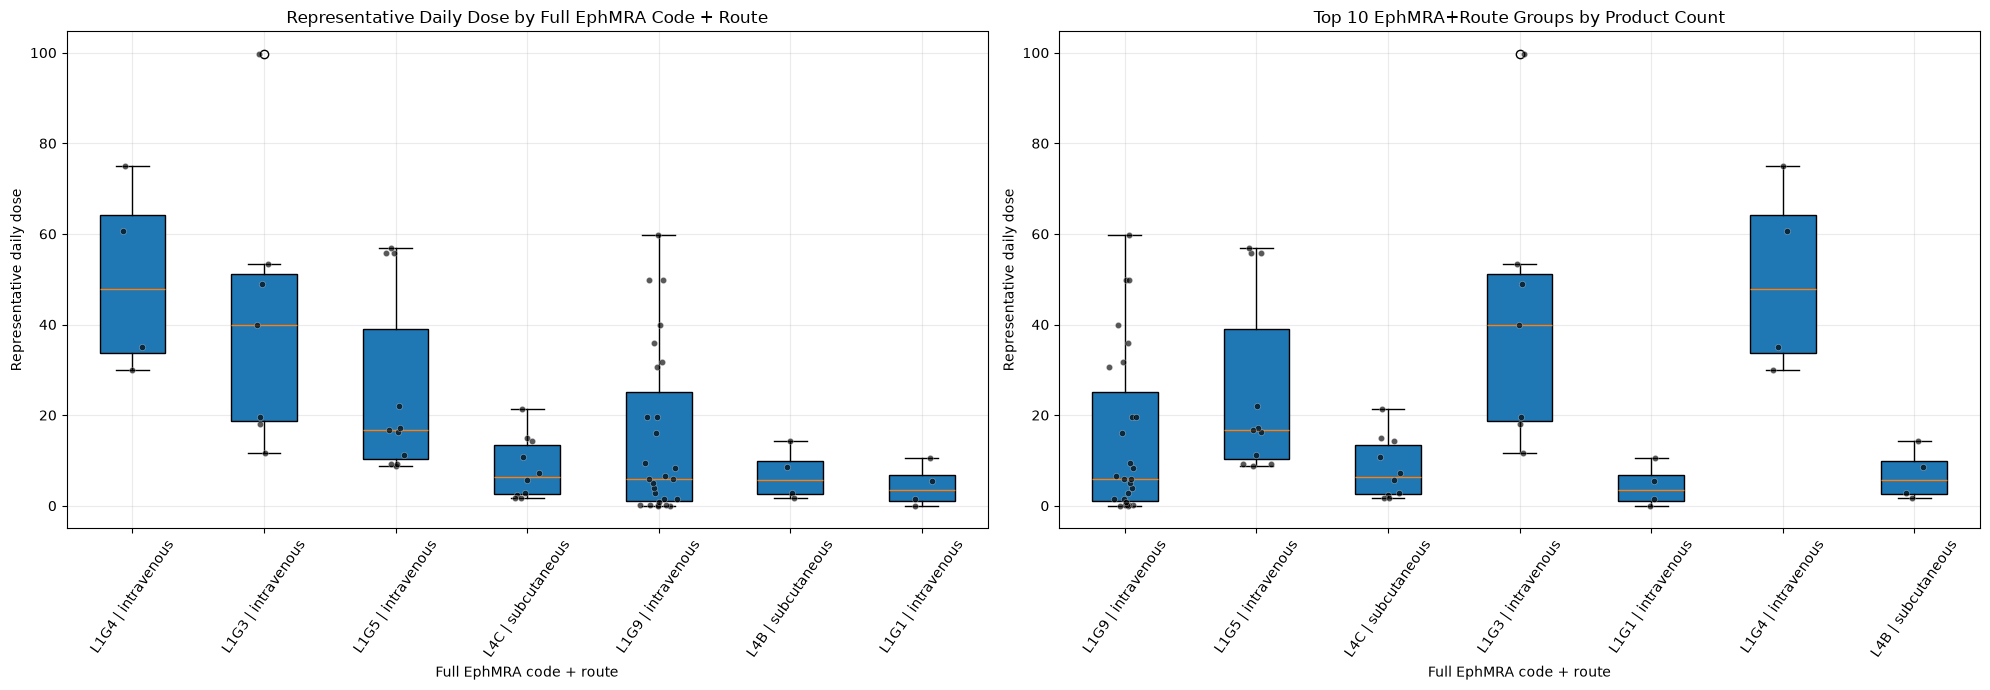

In [9]:
# MODEL 2 box plots (representative daily-dose distributions by full EphMRA code + route)
if 'model2_df' not in globals() or len(model2_df) == 0:
    print('Run Model 2 first to create model2_df.')
else:
    plot_df = model2_df[['ephmra_code', 'route', 'base_name', 'representative_daily_dose']].copy()
    plot_df['ephmra_code_short'] = plot_df['ephmra_code'].astype(str).str.split('(').str[0].str.strip()
    plot_df['group_key'] = plot_df['ephmra_code_short'] + ' | ' + plot_df['route'].astype(str)
    plot_df = plot_df.dropna(subset=['representative_daily_dose'])

    # Full panel order: by median representative daily dose (descending)
    group_order = (
        plot_df.groupby('group_key')['representative_daily_dose']
        .median()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    # Top-10 panel order: by unique product count (descending)
    top_group_order = (
        plot_df.groupby('group_key')['base_name']
        .nunique()
        .sort_values(ascending=False)
        .head(10)
        .index
        .tolist()
    )

    fig, axes = plt.subplots(1, 2, figsize=(20, 7))

    def boxplot_with_dots_model2(ax, frame, order, title):
        groups = [frame.loc[frame['group_key'] == key, 'representative_daily_dose'].values for key in order]

        ax.boxplot(groups, tick_labels=order, patch_artist=True)
        for idx, values in enumerate(groups, start=1):
            jitter = np.random.normal(loc=idx, scale=0.05, size=len(values))
            ax.scatter(jitter, values, s=20, alpha=0.65, color='black', edgecolors='white', linewidths=0.3, zorder=3)
        ax.set_title(title)
        ax.set_xlabel('Full EphMRA code + route')
        ax.set_ylabel('Representative daily dose')
        ax.grid(alpha=0.25)
        ax.tick_params(axis='x', rotation=55)

    # Box plot A: all eligible full EphMRA code + route groups
    boxplot_with_dots_model2(axes[0], plot_df, group_order, 'Representative Daily Dose by Full EphMRA Code + Route')

    # Box plot B: top 10 groups by unique product count
    top_plot_df = plot_df[plot_df['group_key'].isin(top_group_order)].copy()
    boxplot_with_dots_model2(axes[1], top_plot_df, top_group_order, 'Top 10 EphMRA+Route Groups by Product Count')

    plt.tight_layout()
    plt.show()

In [10]:
# MODEL 2 significance + predictive validation (EphMRA code + route -> representative daily dose)
if 'model2_df' not in globals() or len(model2_df) == 0:
    print('Run Model 2 first to create model2_df.')
else:
    from sklearn.model_selection import KFold

    stats2_df = model2_df[['ephmra_code', 'route', 'base_name', 'representative_daily_dose']].dropna().copy()
    stats2_df['ephmra_code_short'] = stats2_df['ephmra_code'].astype(str).str.split('(').str[0].str.strip()
    stats2_df['route'] = stats2_df['route'].astype(str).str.strip().str.lower()
    stats2_df['group_key'] = stats2_df['ephmra_code_short'] + ' | ' + stats2_df['route']
    stats2_df['log_dose'] = np.log1p(stats2_df['representative_daily_dose'])

    # ----- 1) Global significance tests across EphMRA+route groups -----
    grouped = [g['log_dose'].values for _, g in stats2_df.groupby('group_key')]
    k_groups = len(grouped)
    n_total = len(stats2_df)

    if k_groups < 2:
        print('Not enough EphMRA+route groups for inferential testing.')
    else:
        # One-way ANOVA on log-dose
        anova_f, anova_p = sp.stats.f_oneway(*grouped)

        # Eta-squared effect size
        grand_mean = stats2_df['log_dose'].mean()
        ss_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in grouped)
        ss_total = np.sum((stats2_df['log_dose'] - grand_mean) ** 2)
        eta_squared = ss_between / ss_total if ss_total > 0 else np.nan

        # Kruskal-Wallis (non-parametric)
        kruskal_h, kruskal_p = sp.stats.kruskal(*grouped)
        epsilon_squared = (kruskal_h - k_groups + 1) / (n_total - k_groups) if (n_total - k_groups) > 0 else np.nan

        inferential_summary = pd.DataFrame([
            {
                'test': 'ANOVA on log1p(dose)',
                'statistic': anova_f,
                'p_value': anova_p,
                'effect_size_name': 'eta_squared',
                'effect_size': eta_squared,
            },
            {
                'test': 'Kruskal-Wallis on log1p(dose)',
                'statistic': kruskal_h,
                'p_value': kruskal_p,
                'effect_size_name': 'epsilon_squared',
                'effect_size': epsilon_squared,
            },
        ])

        print('=== MODEL 2: Global significance tests (EphMRA code + route vs representative daily dose) ===')
        print(inferential_summary.round(6).to_string(index=False))

    # ----- 2) Predictive validation: baseline vs EphMRA+route model -----
    # Baseline predicts train-fold mean dose; model predicts from EphMRA code + route.
    X = stats2_df[['ephmra_code_short', 'route']].copy()
    y = stats2_df['representative_daily_dose'].values

    n_splits = 5 if len(stats2_df) >= 25 else 3
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    baseline_rows = []
    model_rows = []

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Baseline
        yhat_base = np.repeat(np.mean(y_train), len(y_test))
        baseline_rows.append({
            'fold': fold_idx,
            'r2': r2_score(y_test, yhat_base),
            'mae': mean_absolute_error(y_test, yhat_base),
            'rmse': mean_squared_error(y_test, yhat_base) ** 0.5,
        })

        # EphMRA+route model
        model = Pipeline(steps=[
            ('prep', ColumnTransformer(
                transformers=[
                    ('cat', OneHotEncoder(handle_unknown='ignore'), ['ephmra_code_short', 'route'])
                ],
                remainder='drop',
            )),
            ('reg', LinearRegression()),
        ])
        model.fit(X_train, y_train)
        yhat_model = model.predict(X_test)

        model_rows.append({
            'fold': fold_idx,
            'r2': r2_score(y_test, yhat_model),
            'mae': mean_absolute_error(y_test, yhat_model),
            'rmse': mean_squared_error(y_test, yhat_model) ** 0.5,
        })

    baseline_cv = pd.DataFrame(baseline_rows)
    model_cv = pd.DataFrame(model_rows)

    def ci95(series):
        vals = pd.Series(series).dropna().to_numpy(dtype=float)
        n = len(vals)
        if n == 0:
            return np.nan, np.nan, np.nan
        mean_v = float(np.mean(vals))
        if n == 1:
            return mean_v, np.nan, np.nan
        se = float(np.std(vals, ddof=1) / np.sqrt(n))
        half = 1.96 * se
        return mean_v, mean_v - half, mean_v + half

    base_r2_mean, base_r2_ci_low, base_r2_ci_high = ci95(baseline_cv['r2'])
    base_mae_mean, base_mae_ci_low, base_mae_ci_high = ci95(baseline_cv['mae'])
    base_rmse_mean, base_rmse_ci_low, base_rmse_ci_high = ci95(baseline_cv['rmse'])

    model_r2_mean, model_r2_ci_low, model_r2_ci_high = ci95(model_cv['r2'])
    model_mae_mean, model_mae_ci_low, model_mae_ci_high = ci95(model_cv['mae'])
    model_rmse_mean, model_rmse_ci_low, model_rmse_ci_high = ci95(model_cv['rmse'])

    cv_summary = pd.DataFrame([
        {
            'model': 'Baseline (global mean)',
            'cv_r2_mean': base_r2_mean,
            'cv_r2_ci95_low': base_r2_ci_low,
            'cv_r2_ci95_high': base_r2_ci_high,
            'cv_mae_mean': base_mae_mean,
            'cv_mae_ci95_low': base_mae_ci_low,
            'cv_mae_ci95_high': base_mae_ci_high,
            'cv_rmse_mean': base_rmse_mean,
            'cv_rmse_ci95_low': base_rmse_ci_low,
            'cv_rmse_ci95_high': base_rmse_ci_high,
        },
        {
            'model': 'EphMRA+route linear model',
            'cv_r2_mean': model_r2_mean,
            'cv_r2_ci95_low': model_r2_ci_low,
            'cv_r2_ci95_high': model_r2_ci_high,
            'cv_mae_mean': model_mae_mean,
            'cv_mae_ci95_low': model_mae_ci_low,
            'cv_mae_ci95_high': model_mae_ci_high,
            'cv_rmse_mean': model_rmse_mean,
            'cv_rmse_ci95_low': model_rmse_ci_low,
            'cv_rmse_ci95_high': model_rmse_ci_high,
        },
    ])

    # Fold-level uplift distributions for CI on improvement metrics.
    delta_r2 = model_cv['r2'] - baseline_cv['r2']
    mae_reduction_pct = 100 * (baseline_cv['mae'] - model_cv['mae']) / baseline_cv['mae'].replace(0, np.nan)
    rmse_reduction_pct = 100 * (baseline_cv['rmse'] - model_cv['rmse']) / baseline_cv['rmse'].replace(0, np.nan)

    dr2_mean, dr2_ci_low, dr2_ci_high = ci95(delta_r2)
    mae_red_mean, mae_red_ci_low, mae_red_ci_high = ci95(mae_reduction_pct)
    rmse_red_mean, rmse_red_ci_low, rmse_red_ci_high = ci95(rmse_reduction_pct)

    uplift = pd.DataFrame([
        {
            'metric': 'delta_r2 (model - baseline)',
            'mean_value': dr2_mean,
            'ci95_low': dr2_ci_low,
            'ci95_high': dr2_ci_high,
        },
        {
            'metric': 'mae_reduction_pct',
            'mean_value': mae_red_mean,
            'ci95_low': mae_red_ci_low,
            'ci95_high': mae_red_ci_high,
        },
        {
            'metric': 'rmse_reduction_pct',
            'mean_value': rmse_red_mean,
            'ci95_low': rmse_red_ci_low,
            'ci95_high': rmse_red_ci_high,
        },
    ])

    print('\n=== MODEL 2: Cross-validated predictive performance (with 95% CI) ===')
    print(cv_summary.round(6).to_string(index=False))
    print('\n=== MODEL 2: Predictive uplift from EphMRA code + route (with 95% CI) ===')
    print(uplift.round(6).to_string(index=False))

    # ----- 3) Permutation test on predictive R2 -----
    # Null: EphMRA+route labels are not related to dose.
    observed_r2 = model_cv['r2'].mean()
    n_perm = 500
    perm_r2 = []

    split_indices = list(kf.split(X))
    for _ in range(n_perm):
        X_perm = X.copy()
        X_perm['ephmra_code_short'] = np.random.permutation(X_perm['ephmra_code_short'].values)
        X_perm['route'] = np.random.permutation(X_perm['route'].values)

        fold_r2 = []
        for train_idx, test_idx in split_indices:
            X_train, X_test = X_perm.iloc[train_idx], X_perm.iloc[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            perm_model = Pipeline(steps=[
                ('prep', ColumnTransformer(
                    transformers=[
                        ('cat', OneHotEncoder(handle_unknown='ignore'), ['ephmra_code_short', 'route'])
                    ],
                    remainder='drop',
                )),
                ('reg', LinearRegression()),
            ])
            perm_model.fit(X_train, y_train)
            yhat_perm = perm_model.predict(X_test)
            fold_r2.append(r2_score(y_test, yhat_perm))

        perm_r2.append(np.mean(fold_r2))

    perm_r2 = np.array(perm_r2)
    p_perm = (np.sum(perm_r2 >= observed_r2) + 1) / (n_perm + 1)

    permutation_summary = pd.DataFrame([
        {
            'observed_cv_r2': observed_r2,
            'perm_mean_r2': perm_r2.mean(),
            'perm_std_r2': perm_r2.std(ddof=1),
            'perm_p_value_one_sided': p_perm,
            'n_permutations': n_perm,
        }
    ])

    print('\n=== MODEL 2: Permutation test for predictive signal ===')
    print(permutation_summary.round(6).to_string(index=False))


=== MODEL 2: Global significance tests (EphMRA code + route vs representative daily dose) ===
                         test  statistic  p_value effect_size_name  effect_size
         ANOVA on log1p(dose)   4.894020 0.000394      eta_squared     0.328590
Kruskal-Wallis on log1p(dose)  23.501529 0.000645  epsilon_squared     0.291692

=== MODEL 2: Cross-validated predictive performance (with 95% CI) ===
                    model  cv_r2_mean  cv_r2_ci95_low  cv_r2_ci95_high  cv_mae_mean  cv_mae_ci95_low  cv_mae_ci95_high  cv_rmse_mean  cv_rmse_ci95_low  cv_rmse_ci95_high
   Baseline (global mean)   -0.031631       -0.068529         0.005266    16.955281        13.795774         20.114787     21.101154         16.718537          25.483771
EphMRA+route linear model    0.136890       -0.274339         0.548118    14.687285        12.263951         17.110618     18.383782         14.945825          21.821738

=== MODEL 2: Predictive uplift from EphMRA code + route (with 95% CI) ===
          

In [11]:
# MODEL 2: predicted representative daily dose per EphMRA+route group (expanded stats, cross-validated bias)
if 'model2_df' not in globals() or len(model2_df) == 0:
    print('Run Model 2 first to create model2_df.')
else:
    from sklearn.model_selection import KFold

    pred2_df = model2_df[['ephmra_code', 'route', 'base_name', 'representative_daily_dose']].dropna().copy()
    pred2_df['ephmra_code_short'] = pred2_df['ephmra_code'].astype(str).str.split('(').str[0].str.strip()
    pred2_df['route'] = pred2_df['route'].astype(str).str.strip().str.lower()
    pred2_df['group_key'] = pred2_df['ephmra_code_short'] + ' | ' + pred2_df['route']

    # Build out-of-fold predictions so per-group bias is measured out-of-sample.
    n_rows = len(pred2_df)
    n_splits = 5 if n_rows >= 25 else 3
    n_splits = min(n_splits, n_rows)

    if n_splits < 2:
        print('Not enough rows for cross-validated prediction summary.')
    else:
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        oof_pred = np.zeros(n_rows, dtype=float)

        X_all = pred2_df[['ephmra_code_short', 'route']].copy()
        y_all = pred2_df['representative_daily_dose'].values

        for train_idx, test_idx in kf.split(X_all):
            X_train, X_test = X_all.iloc[train_idx], X_all.iloc[test_idx]
            y_train = y_all[train_idx]

            fold_model = Pipeline(steps=[
                ('prep', ColumnTransformer(
                    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), ['ephmra_code_short', 'route'])],
                    remainder='drop',
                )),
                ('reg', LinearRegression()),
            ])

            fold_model.fit(X_train, y_train)
            oof_pred[test_idx] = fold_model.predict(X_test)

        pred2_df['cv_predicted_daily_dose'] = oof_pred
        pred2_df['cv_residual'] = pred2_df['representative_daily_dose'] - pred2_df['cv_predicted_daily_dose']

        # Build per-group summary using cross-validated (out-of-fold) predictions.
        predictions_per_group = (
            pred2_df.groupby('group_key')
            .agg(
                n_products=('base_name', 'nunique'),
                actual_mean_daily_dose=('representative_daily_dose', 'mean'),
                cv_predicted_daily_dose=('cv_predicted_daily_dose', 'mean'),
                std_daily_dose=('representative_daily_dose', 'std'),
                median_daily_dose=('representative_daily_dose', 'median'),
                q1_daily_dose=('representative_daily_dose', lambda s: s.quantile(0.25)),
                q3_daily_dose=('representative_daily_dose', lambda s: s.quantile(0.75)),
                min_daily_dose=('representative_daily_dose', 'min'),
                max_daily_dose=('representative_daily_dose', 'max'),
                cv_mae_within_group=('cv_residual', lambda s: np.mean(np.abs(s))),
                cv_rmse_within_group=('cv_residual', lambda s: np.sqrt(np.mean(np.square(s)))),
            )
            .sort_values(['n_products', 'cv_predicted_daily_dose'], ascending=[False, False])
        )

        predictions_per_group['se_mean'] = predictions_per_group['std_daily_dose'] / np.sqrt(predictions_per_group['n_products'])
        predictions_per_group['ci95_low'] = predictions_per_group['actual_mean_daily_dose'] - 1.96 * predictions_per_group['se_mean']
        predictions_per_group['ci95_high'] = predictions_per_group['actual_mean_daily_dose'] + 1.96 * predictions_per_group['se_mean']
        predictions_per_group['ci95_half_width'] = 1.96 * predictions_per_group['se_mean']
        predictions_per_group['iqr_daily_dose'] = predictions_per_group['q3_daily_dose'] - predictions_per_group['q1_daily_dose']
        predictions_per_group['cv_pct'] = np.where(
            predictions_per_group['actual_mean_daily_dose'] != 0,
            100 * predictions_per_group['std_daily_dose'] / predictions_per_group['actual_mean_daily_dose'],
            np.nan,
        )
        predictions_per_group['cv_bias_pred_minus_actual'] = (
            predictions_per_group['cv_predicted_daily_dose'] - predictions_per_group['actual_mean_daily_dose']
        )

        predictions_per_group['cv_predicted_daily_dose_ci95'] = predictions_per_group.apply(
            lambda r: f"{r['cv_predicted_daily_dose']:.2f} (+/- {r['ci95_half_width']:.2f} CI95)",
            axis=1,
        )

        ordered_cols = [
            'n_products',
            'actual_mean_daily_dose',
            'cv_predicted_daily_dose_ci95',
            'cv_bias_pred_minus_actual',
            'std_daily_dose',
            'se_mean',
            'ci95_low',
            'ci95_high',
            'median_daily_dose',
            'q1_daily_dose',
            'q3_daily_dose',
            'iqr_daily_dose',
            'min_daily_dose',
            'max_daily_dose',
            'cv_pct',
            'cv_mae_within_group',
            'cv_rmse_within_group',
        ]

        print('=== MODEL 2: Cross-validated predictions per EphMRA+route group (expanded statistics) ===')
        print(predictions_per_group[ordered_cols].round(4).to_string())


=== MODEL 2: Cross-validated predictions per EphMRA+route group (expanded statistics) ===
                    n_products  actual_mean_daily_dose cv_predicted_daily_dose_ci95  cv_bias_pred_minus_actual  std_daily_dose  se_mean  ci95_low  ci95_high  median_daily_dose  q1_daily_dose  q3_daily_dose  iqr_daily_dose  min_daily_dose  max_daily_dose    cv_pct  cv_mae_within_group  cv_rmse_within_group
group_key                                                                                                                                                                                                                                                                                                         
L1G9 | intravenous          27                 14.9956        14.12 (+/- 6.88 CI95)                    -0.8789         18.2383   3.5100    8.1160    21.8751              5.870         1.1100        25.1200         24.0100            0.01           59.84  121.6246              16.4059            